# Israeli Election-Campaign SMS Classifier

## Part 1 - Introduction

### Student details

| Field | Value |
|---|---|
| Student | **Yaniv B.** |
| Last 4 ID digits | **9671** |
| Assignment type | Text Analysis / NLP |
| Learning type | Supervised Binary Classification |
| Implemented algorithm | Multinomial Naive Bayes - implemented from scratch |
| Kaggle dataset | Israeli Election SMS Filtering |
| Dataset URL | https://www.kaggle.com/datasets/yanivbahalul/israeli-election-sms-filtering |

### Project goal

The goal of this project is to classify Israeli Hebrew SMS messages into two classes:

- **`political`** - election-campaign or election-related political SMS whose main purpose is related to voting, candidates, parties, campaign activity, election polling, political mobilisation, or campaign promotion.
- **`non_political`** - ordinary SMS such as commercial, transactional, delivery, service, official, or other messages whose main purpose is not election campaigning.

This is a **binary text-classification problem**. The central class for evaluation is `political`, so the primary quality metric used throughout the notebook is **F1 for the political class**.

### Dataset

The project uses the two files supplied in the Kaggle dataset:

- `train.csv` - used for feature engineering, model training, and 5-fold cross-validation.
- `test.csv` - kept separate and used only for the final evaluation.

The notebook **does not split these files again into a new Train/Test split**. During model selection, only the provided Train set is divided internally into five cross-validation folds.

The dataset was prepared specifically for this project and contains curated Israeli SMS examples. Before publication, the data was privacy-audited: messages containing personal identifiers used during collection, HIT-related personal content, authentication/verification-code messages, and other sensitive personal categories were removed. Controlled synthetic election-related examples were also used to improve political-class coverage. The final published Kaggle `train.csv` and `test.csv` files are treated as fixed throughout the modelling flow.

### Learning algorithm

We implement **Multinomial Naive Bayes from scratch** using NumPy and Python data structures. No scikit-learn classifier, vectorizer, metric implementation, or train/test split utility is used.

The model is evaluated and tuned with:

- Hebrew-aware tokenization
- optional stopword removal
- unigram / unigram+bigram feature engineering
- vocabulary filtering with `min_df`
- Laplace smoothing parameter `alpha`
- empirical or equal class priors
- a decision threshold for the central `political` class
- 5-fold cross-validation on Train only

### AI / LLM assistance disclosure

AI tools were used as an aid for code review, notebook organisation, dataset auditing, and presentation. The project code, model logic, outputs, and conclusions were reviewed and must be understood and explained by the student.

Representative prompts actually used during the project included:

| Prompt | Purpose |
|---|---|
| `תעבור על המחברת בצורה טובה ותוודא שהיא מקצועית ובהתאם לדרישות המטלה.` | Review notebook structure and assignment compliance |
| `תסנן מה-dataset הודעות שקשורות לציונים, רפואה, מרפאה, תקלות ודברים אישיים שקשורים לעבודה, אבל תשאיר משלוחים והודעות רגילות.` | Dataset auditing and privacy filtering |
| `תשנה רק את חלקי הקוד הנדרשים ותוודא שה-Train וה-Test נשארים נפרדים ללא leakage.` | Code review and leakage-control assistance |

These prompts were used for assistance only; the final implementation and interpretation are contained in this notebook.


### Main modelling strategy

The **main classifier in this notebook is a 10-model balanced ensemble**.

Each learner is an independently trained instance of the same **Multinomial Naive Bayes** implementation.  
For every learner, a different random class-balanced subset of the Train set is sampled.  
At prediction time, all 10 learners classify the SMS independently and the final class is selected by **majority vote**.

So the project still implements **one learning algorithm — Multinomial Naive Bayes** — while the final classifier uses an ensemble strategy around that algorithm.


### Final classifier

The final classifier is a **Balanced Ensemble of 10 Multinomial Naive Bayes learners**.

Each learner is trained on a different random class-balanced subset of Train.  
At prediction time, all ten learners independently vote `political` or `non_political`, and the final SMS label is selected by **majority vote**.

Only one learning algorithm is implemented: **Multinomial Naive Bayes**.  
The ensemble is the strategy used to combine ten independently trained instances of that same algorithm.


In [ ]:
# Google Colab setup
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "kagglehub[pandas-datasets]",
])

print("Colab environment ready.")


Colab environment ready.


In [ ]:
import json
import math
import os
import re
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

RANDOM_SEED = 42
POSITIVE_LABEL = "political"
NEGATIVE_LABEL = "non_political"
LABELS = [NEGATIVE_LABEL, POSITIVE_LABEL]

pd.set_option("display.max_colwidth", 140)
np.random.seed(RANDOM_SEED)


def display_rtl_table(frame, text_columns=("message", "original_message")):
    """Display Hebrew text right-to-left while keeping normal DataFrame rendering."""
    columns = [column for column in text_columns if column in frame.columns]
    if not columns:
        display(frame)
        return

    styled = (
        frame.style
        .set_properties(
            subset=columns,
            **{
                "direction": "rtl",
                "text-align": "right",
                "unicode-bidi": "plaintext",
                "white-space": "normal",
                "min-width": "280px",
                "max-width": "620px",
            },
        )
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "td", "props": [("vertical-align", "top")]},
        ])
    )
    display(styled)


plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})


### Load the prepared Train and Test files

The latest published `train.csv` and `test.csv` are loaded **directly from the Kaggle dataset**.

The supplied split is treated as fixed:

- Train is used for feature engineering, hyperparameter selection and final training.
- Test is never used for training or model selection.
- Test labels are used only after predictions are produced, for final evaluation.


In [ ]:
# Load the latest train.csv and test.csv directly from Kaggle.
import kagglehub
from kagglehub import KaggleDatasetAdapter

DATASET = "yanivbahalul/israeli-election-sms-filtering"

df_train = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET,
    "train.csv",
)

df_test = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET,
    "test.csv",
)

print("Latest Kaggle dataset loaded successfully.")
print(f"Train rows: {len(df_train):,}")
print(f"Test rows:  {len(df_test):,}")

dataset_summary_df = pd.DataFrame([
    {
        "split": "Train",
        "rows": len(df_train),
        "political": int((df_train["label"] == POSITIVE_LABEL).sum()),
        "non_political": int((df_train["label"] == NEGATIVE_LABEL).sum()),
    },
    {
        "split": "Test",
        "rows": len(df_test),
        "political": int((df_test["label"] == POSITIVE_LABEL).sum()),
        "non_political": int((df_test["label"] == NEGATIVE_LABEL).sum()),
    },
])

display(dataset_summary_df)

print("\nFirst 5 Train rows:")
display_rtl_table(df_train.head())

print("\nFirst 5 Test rows:")
display_rtl_table(df_test.head())


Using Colab cache for faster access to the 'israeli-election-sms-filtering' dataset.
Using Colab cache for faster access to the 'israeli-election-sms-filtering' dataset.
Latest Kaggle dataset loaded successfully.
Train rows: 5,094
Test rows:  2,626


,split,rows,political,non_political
0,Train,5094,2939,2155
1,Test,2626,1496,1130



First 5 Train rows:


,message,label
0,Notificare despre cont: parola pentru Contul Google playerone381@gmail.com a fost modificată recent. google.com/password,non_political
1,שבוע לבחירות בצל המלחמה: מדגם קצר על המתמודדים לראשות העיר חיפה בבחירות שייערכו בעוד שבוע בדיוק. המדגם נפתח. השפיעו על זהות ראש העיר הבא שלכם >>> https://q.dpolls.me/774854d1,non_political
2,סקר בחירות: עד כמה אתה עוקב אחרי מערכת בחירות 2022 ? 1. במידה רבה מאוד 2. במידה רבה 3. מעט 4. כמעט לא,political
3,"לקראת יום הבחירות: מי לדעתך מוביל כרגע במערכת הבחירות? 1. עוצמה יהודית 2. הליכוד 3. ש""ס 4. הבית הציוני 5. הרשימה המשותפת 6. ביחד 7. ישר השיבו באפשרות המתאימה.",political
4,The code to disable or move your Steam Authenticator is: 89397,non_political



First 5 Test rows:


,message,label
0,"משרתי מילואים יקרים, כחלק ממעטפת הפרט למשרתי המילואים ולבני משפחותיהם, ומתוך הוקרה עמוקה והערכה רבה על שירותך במילואים, תשלום התגמול הנוסף שיועבר על-ידי רשות המיסים, בעבור ימי המילואים שביצעת בשנת 2024, הוקדם לתאריך 8/4/2025 (במקום בתאריך 1/5/25). התגמול ישולם ישירות לחשבון הבנק כפי שמדווח במערכות צה״ל. מצורפת אגרת https://go.idf.il/q3a3r5f1q4 לצפייה בסרטון ההסבר https://go.idf.il/TagmoolNosaf בהערכה רבה, אגף כח האדם",non_political
1,סקר מנדטים 2019: איזו מפלגה לדעתך תסיים את מערכת הבחירות חזקה יותר מהמצב שלה כיום? 1. ישראל ביתנו 2. כולנו 3. יהדות התורה 4. העבודה 5. כחול לבן 6. מרצ 7. הליכוד,political
2,משלוח 80034059 נמסר לאצל נשומר. נשמח לדירוג הנהג בין 1 (נמוך) ל 10 (גבוה) בהודעה חוזרת. לפרטים נוספים https://ilto.run/c9H7QHxZ2O בברכה צ'יטה שליחויות,non_political
3,סקר מנדטים 2019: איזו מפלגה לדעתך תסיים את מערכת הבחירות חזקה יותר מהמצב שלה כיום? 1. העבודה 2. הליכוד 3. ישראל ביתנו 4. יהדות התורה 5. כחול לבן 6. כולנו 7. מרצ,political
4,"סטודנטים יקרים, ראו מייל שנשלח אליכם בנושא ""התאמות למשרתים בכוחות הבטחון"" חשוב מאוד לקרוא בעיון רב. בברכה, יעל לביא-רכזת סטודנטים",non_political


### Dataset integrity and leakage checks

Before modelling, the notebook verifies the required schema, labels, missing values, empty messages, exact duplicates, and exact Train/Test overlap.

Exact Train/Test leakage is treated as a hard failure. A stronger punctuation-insensitive fingerprint is also reported as a **diagnostic only**, because harmless formatting differences should not stop the experiment.


In [ ]:
EXPECTED_COLUMNS = ["message", "label"]
EXPECTED_LABELS = {NEGATIVE_LABEL, POSITIVE_LABEL}


def exact_fingerprint(message):
    """Normalize only Unicode/case/whitespace for true duplicate/leakage checks."""
    text = unicodedata.normalize("NFKC", str(message)).casefold()
    return re.sub(r"\s+", " ", text).strip()


def normalized_fingerprint(message):
    """Stronger diagnostic fingerprint for near-duplicate reporting only."""
    text = unicodedata.normalize("NFKC", str(message)).casefold()
    text = re.sub(r"<(?:URL|PHONE|EMAIL|NAME)>", "<X>", text, flags=re.I)
    return re.sub(r"[^0-9a-zא-ת<>]+", "", text)


for split_name, frame in [("Train", df_train), ("Test", df_test)]:
    assert frame.columns.tolist() == EXPECTED_COLUMNS, (
        f"{split_name} columns must be exactly {EXPECTED_COLUMNS}; got {frame.columns.tolist()}"
    )
    assert not frame[EXPECTED_COLUMNS].isna().any().any(), f"{split_name} contains missing values"
    assert set(frame["label"]) == EXPECTED_LABELS, f"Unexpected labels in {split_name}"
    assert (frame["message"].str.strip().str.len() > 0).all(), f"{split_name} contains empty messages"

# Exact duplicate/leakage checks: these are hard failures.
train_exact = df_train["message"].map(exact_fingerprint)
test_exact = df_test["message"].map(exact_fingerprint)

assert not train_exact.duplicated().any(), "Exact duplicate messages found inside Train"
assert not test_exact.duplicated().any(), "Exact duplicate messages found inside Test"

train_exact_set = set(train_exact)
test_exact_set = set(test_exact)
assert not (train_exact_set & test_exact_set), "Exact Train/Test leakage detected"

# Stronger normalization is useful for diagnostics, but harmless punctuation/URL
# formatting variants should not stop the notebook from running.
train_near = df_train["message"].map(normalized_fingerprint)
test_near = df_test["message"].map(normalized_fingerprint)
train_near_set = set(train_near)
test_near_set = set(test_near)

near_overlap = train_near_set & test_near_set
train_near_duplicates = int(train_near.duplicated().sum())
test_near_duplicates = int(test_near.duplicated().sum())

integrity_df = pd.DataFrame([
    {
        "split": name,
        "rows": len(frame),
        "missing_messages": int(frame["message"].isna().sum()),
        "exact_duplicates": int(frame["message"].map(exact_fingerprint).duplicated().sum()),
        "near_duplicate_fingerprints": int(frame["message"].map(normalized_fingerprint).duplicated().sum()),
        "political": int((frame["label"] == POSITIVE_LABEL).sum()),
        "non_political": int((frame["label"] == NEGATIVE_LABEL).sum()),
    }
    for name, frame in [("Train", df_train), ("Test", df_test)]
])

print("Exact Train/Test overlap:", len(train_exact_set & test_exact_set))
print("Near-duplicate Train/Test overlap (diagnostic only):", len(near_overlap))
print("Near-duplicate fingerprints inside Train:", train_near_duplicates)
print("Near-duplicate fingerprints inside Test:", test_near_duplicates)
display(integrity_df)


Exact Train/Test overlap: 0
Near-duplicate Train/Test overlap (diagnostic only): 0
Near-duplicate fingerprints inside Train: 2
Near-duplicate fingerprints inside Test: 0


,split,rows,missing_messages,exact_duplicates,near_duplicate_fingerprints,political,non_political
0,Train,5094,0,0,2,2939,2155
1,Test,2626,0,0,0,1496,1130


### Class distribution

The exact counts and percentages are shown in the table.  
A single compact chart is used only to compare the **class balance** between Train and Test.


Class distribution:


,Train count,Train %,Test count,Test %
label,,,,
non_political,2155,42.3,1130,43.0
political,2939,57.7,1496,57.0


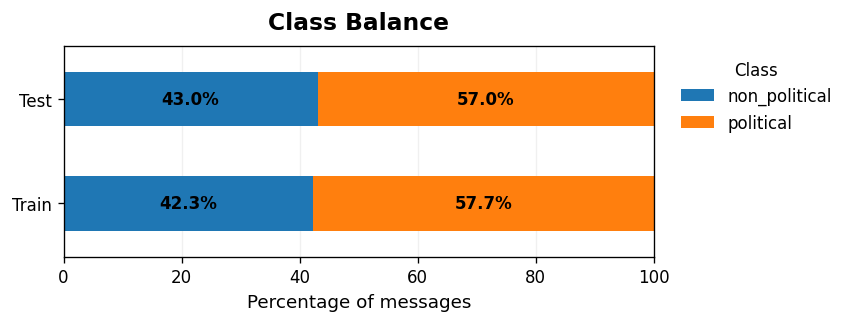

Dataset sizes: Train = 5,094 messages | Test = 2,626 messages


In [ ]:

class_order = [NEGATIVE_LABEL, POSITIVE_LABEL]

distribution_counts = pd.DataFrame({
    "Train": df_train["label"].value_counts().reindex(class_order),
    "Test": df_test["label"].value_counts().reindex(class_order),
}).fillna(0).astype(int)

distribution_percent = (
    distribution_counts
    .div(distribution_counts.sum(axis=0), axis=1)
    .mul(100)
)

distribution_table = pd.DataFrame({
    "Train count": distribution_counts["Train"],
    "Train %": distribution_percent["Train"].round(1),
    "Test count": distribution_counts["Test"],
    "Test %": distribution_percent["Test"].round(1),
})

print("Class distribution:")
display(distribution_table)

plot_df = distribution_percent.T[class_order]

ax = plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(7.2, 2.8),
    width=0.52,
)

ax.set_title("Class Balance", pad=10, fontweight="bold")
ax.set_xlabel("Percentage of messages")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(
    title="Class",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.grid(axis="x", alpha=0.18)
ax.set_axisbelow(True)

for row_index, split_name in enumerate(plot_df.index):
    cumulative = 0.0
    for class_name in class_order:
        value = float(plot_df.loc[split_name, class_name])
        ax.text(
            cumulative + value / 2,
            row_index,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontweight="bold",
            fontsize=10,
        )
        cumulative += value

plt.tight_layout()
plt.show()

print(
    f"Dataset sizes: Train = {len(df_train):,} messages | "
    f"Test = {len(df_test):,} messages"
)


### Data-specific adaptation

Balanced random sampling is part of the **main final classifier**.

The final classifier contains **10 independent Multinomial Naive Bayes learners**.  
For each learner:

1. a new random subset is drawn from Train;
2. the subset contains the same number of `political` and `non_political` messages;
3. the selected feature engineering is applied;
4. the learner is trained independently;
5. during prediction, all ten learners vote.

The Test set is never sampled and never used for training or hyperparameter selection.

The ensemble size is fixed at **10 learners**. The feature-engineering and Naive Bayes hyperparameters are selected with Train-only 5-fold cross-validation.


In [ ]:
train_class_share = (
    df_train["label"]
    .value_counts(normalize=True)
    .reindex(LABELS)
    .rename("share")
    .to_frame()
)
train_class_share["percent"] = (100 * train_class_share["share"]).round(2)
train_class_share.index.name = "class"

print("Train class proportions used for model fitting:")
display(train_class_share)


Train class proportions used for model fitting:


,share,percent
class,,
non_political,0.423047,42.3
political,0.576953,57.7


---

## Part 2 – Feature Engineering

### Hebrew-aware preprocessing

The preprocessing function receives the SMS text only; it never receives the true label. It:

1. Applies Unicode NFKC normalization and lowercasing.
2. Preserves privacy placeholders such as `<URL>` and `<PHONE>` as meaningful tokens.
3. Extracts Hebrew words, English words, numbers, and placeholders.
4. Optionally removes a small fixed Hebrew stopword list.
5. Optionally adds word bigrams such as `יוצאים__להצביע`.

All vocabulary decisions are learned from training data only. During cross-validation the vocabulary is rebuilt separately inside every fold.


In [ ]:
HEBREW_STOPWORDS = {
    "אני", "את", "אתה", "אתם", "אתן", "אנחנו", "הוא", "היא", "הם", "הן",
    "של", "שלי", "שלך", "שלכם", "שלכן", "שלנו", "על", "אל", "עם", "בלי",
    "גם", "אם", "כי", "אך", "אבל", "או", "אז", "זה", "זו", "זאת", "אלה",
    "כל", "כאן", "שם", "עוד", "כבר", "רק", "מאוד", "יותר", "פחות", "בין",
    "לכל", "לנו", "לכם", "להם", "להן", "אותו", "אותה", "אותם", "אותן",
    "היום", "מחר", "אתמול", "שלום", "היי", "תודה", "בבקשה",
}

TOKEN_RE = re.compile(
    r"<(?:URL|PHONE|EMAIL|NAME)>|"
    r"[א-ת]+(?:[״׳'\"-][א-ת]+)*|"
    r"[A-Za-z]+(?:[-_][A-Za-z]+)*|"
    r"\d+",
    flags=re.I,
)


def preprocess_message(message, remove_stopwords=False, ngram_max=1):
    text = unicodedata.normalize("NFKC", str(message)).casefold()
    raw_tokens = TOKEN_RE.findall(text)
    tokens = []

    for token in raw_tokens:
        upper = token.upper()
        if upper in {"<URL>", "<PHONE>", "<EMAIL>", "<NAME>"}:
            tokens.append(upper[1:-1].lower() + "token")
        elif len(token) > 1 and (not remove_stopwords or token not in HEBREW_STOPWORDS):
            tokens.append(token)

    features = list(tokens)
    if ngram_max >= 2:
        features.extend(f"{a}__{b}" for a, b in zip(tokens, tokens[1:]))
    return features


feature_configs = [
    {"feature_name": "unigrams_keep_stopwords", "remove_stopwords": False, "ngram_max": 1},
    {"feature_name": "unigrams_remove_stopwords", "remove_stopwords": True, "ngram_max": 1},
    {"feature_name": "uni_bigrams_keep_stopwords", "remove_stopwords": False, "ngram_max": 2},
    {"feature_name": "uni_bigrams_remove_stopwords", "remove_stopwords": True, "ngram_max": 2},
]

print("Tokenizer demo:")
demo_message = df_train.iloc[0]["message"]
print("Message:", demo_message[:180].replace("\n", " "))
print("Tokens:", preprocess_message(demo_message, remove_stopwords=False, ngram_max=2)[:30])

Tokenizer demo:
Message: Notificare despre cont: parola pentru Contul Google playerone381@gmail.com a fost modificată recent. google.com/password
Tokens: ['notificare', 'despre', 'cont', 'parola', 'pentru', 'contul', 'google', 'playerone', '381', 'gmail', 'com', 'fost', 'modificat', 'recent', 'google', 'com', 'password', 'notificare__despre', 'despre__cont', 'cont__parola', 'parola__pentru', 'pentru__contul', 'contul__google', 'google__playerone', 'playerone__381', '381__gmail', 'gmail__com', 'com__fost', 'fost__modificat', 'modificat__recent']


### Feature-engineering demonstration on 3 Train messages


In [ ]:
example_rows = []
for row_index in [0, 1, 2]:
    row = df_train.iloc[row_index]
    for config in feature_configs:
        tokens = preprocess_message(
            row["message"],
            remove_stopwords=config["remove_stopwords"],
            ngram_max=config["ngram_max"],
        )
        example_rows.append({
            "row": row_index,
            "label": row["label"],
            "feature_name": config["feature_name"],
            "token_count": len(tokens),
            "first_tokens": " | ".join(tokens[:18]),
        })

feature_examples_df = pd.DataFrame(example_rows)
display_rtl_table(feature_examples_df, text_columns=("first_tokens",))


,row,label,feature_name,token_count,first_tokens
0,0,non_political,unigrams_keep_stopwords,17,notificare | despre | cont | parola | pentru | contul | google | playerone | 381 | gmail | com | fost | modificat | recent | google | com | password
1,0,non_political,unigrams_remove_stopwords,17,notificare | despre | cont | parola | pentru | contul | google | playerone | 381 | gmail | com | fost | modificat | recent | google | com | password
2,0,non_political,uni_bigrams_keep_stopwords,33,notificare | despre | cont | parola | pentru | contul | google | playerone | 381 | gmail | com | fost | modificat | recent | google | com | password | notificare__despre
3,0,non_political,uni_bigrams_remove_stopwords,33,notificare | despre | cont | parola | pentru | contul | google | playerone | 381 | gmail | com | fost | modificat | recent | google | com | password | notificare__despre
4,1,non_political,unigrams_keep_stopwords,29,שבוע | לבחירות | בצל | המלחמה | מדגם | קצר | על | המתמודדים | לראשות | העיר | חיפה | בבחירות | שייערכו | בעוד | שבוע | בדיוק | המדגם | נפתח
5,1,non_political,unigrams_remove_stopwords,26,שבוע | לבחירות | בצל | המלחמה | מדגם | קצר | המתמודדים | לראשות | העיר | חיפה | בבחירות | שייערכו | בעוד | שבוע | בדיוק | המדגם | נפתח | השפיעו
6,1,non_political,uni_bigrams_keep_stopwords,57,שבוע | לבחירות | בצל | המלחמה | מדגם | קצר | על | המתמודדים | לראשות | העיר | חיפה | בבחירות | שייערכו | בעוד | שבוע | בדיוק | המדגם | נפתח
7,1,non_political,uni_bigrams_remove_stopwords,51,שבוע | לבחירות | בצל | המלחמה | מדגם | קצר | המתמודדים | לראשות | העיר | חיפה | בבחירות | שייערכו | בעוד | שבוע | בדיוק | המדגם | נפתח | השפיעו
8,2,political,unigrams_keep_stopwords,18,סקר | בחירות | עד | כמה | אתה | עוקב | אחרי | מערכת | בחירות | 2022 | במידה | רבה | מאוד | במידה | רבה | מעט | כמעט | לא
9,2,political,unigrams_remove_stopwords,16,סקר | בחירות | עד | כמה | עוקב | אחרי | מערכת | בחירות | 2022 | במידה | רבה | במידה | רבה | מעט | כמעט | לא


### Vocabulary and sparse bag-of-words encoding


In [ ]:
def tokenize_messages(messages, feature_config):
    return [
        preprocess_message(
            message,
            remove_stopwords=feature_config["remove_stopwords"],
            ngram_max=feature_config["ngram_max"],
        )
        for message in messages
    ]


def build_vocab(token_lists, min_df=1, max_df_frac=0.95, max_size=10_000):
    n_documents = len(token_lists)
    max_df = max(1, int(max_df_frac * n_documents))
    document_frequency = Counter()

    for tokens in token_lists:
        document_frequency.update(set(tokens))

    eligible = [
        (token, count)
        for token, count in document_frequency.items()
        if min_df <= count <= max_df
    ]
    eligible.sort(key=lambda item: (-item[1], item[0]))
    eligible = eligible[:max_size]
    return {token: token_id for token_id, (token, _) in enumerate(eligible)}


def encode_documents(token_lists, vocab):
    encoded = []
    for tokens in token_lists:
        counts = Counter(vocab[token] for token in tokens if token in vocab)
        encoded.append(counts)
    return encoded


print("Vocabulary and encoding helpers ready.")

Vocabulary and encoding helpers ready.


---

## Part 3 – Learning Algorithm: Multinomial Naive Bayes

Multinomial Naive Bayes models a message as token counts. For a class $c$ and token $t$, training estimates:

$$P(t\mid c)=\frac{N_{t,c}+\alpha}{\sum_j N_{j,c}+\alpha|V|}$$

where $N_{t,c}$ is the token count in class $c$, $|V|$ is vocabulary size, and $\alpha$ is Laplace smoothing. A message $d$ receives the log-score:

$$\log P(c\mid d) \propto \log P(c)+\sum_t n_{t,d}\log P(t\mid c)$$

The implementation compares class scores in log space for numerical stability. `fit_prior=False` uses equal class priors; `fit_prior=True` learns priors from Train. A cross-validated probability threshold converts the political probability into the final binary label.

The class below implements training, log-score prediction, probability prediction, and thresholded binary prediction entirely from scratch.


In [ ]:
class MultinomialNBFromScratch:
    def __init__(self, alpha=1.0, fit_prior=True):
        self.alpha = float(alpha)
        self.fit_prior = bool(fit_prior)
        self.classes_ = None
        self.class_to_index_ = None
        self.log_prior_ = None
        self.log_conditional_ = None
        self.vocab_size_ = None

    def train(self, X_counts, y, vocab_size):
        self.classes_ = sorted(set(y))
        self.class_to_index_ = {label: i for i, label in enumerate(self.classes_)}
        self.vocab_size_ = int(vocab_size)
        n_classes = len(self.classes_)

        class_document_counts = np.zeros(n_classes, dtype=np.float64)
        token_counts = np.zeros((n_classes, self.vocab_size_), dtype=np.float64)

        for document, label in zip(X_counts, y):
            class_index = self.class_to_index_[label]
            class_document_counts[class_index] += 1
            for token_id, count in document.items():
                token_counts[class_index, token_id] += count

        if self.fit_prior:
            self.log_prior_ = np.log(class_document_counts / class_document_counts.sum())
        else:
            self.log_prior_ = np.full(n_classes, -math.log(n_classes), dtype=np.float64)

        smoothed = token_counts + self.alpha
        denominators = smoothed.sum(axis=1, keepdims=True)
        self.log_conditional_ = np.log(smoothed / denominators)
        return self

    def predict_log_scores(self, X_counts):
        all_scores = np.zeros((len(X_counts), len(self.classes_)), dtype=np.float64)
        for row_index, document in enumerate(X_counts):
            scores = self.log_prior_.copy()
            for token_id, count in document.items():
                if token_id < self.vocab_size_:
                    scores += count * self.log_conditional_[:, token_id]
            all_scores[row_index] = scores
        return all_scores

    def predict_proba(self, X_counts):
        log_scores = self.predict_log_scores(X_counts)
        shifted = log_scores - log_scores.max(axis=1, keepdims=True)
        probabilities = np.exp(shifted)
        return probabilities / probabilities.sum(axis=1, keepdims=True)

    def predict(self, X_counts, positive_label=POSITIVE_LABEL, threshold=0.5):
        probabilities = self.predict_proba(X_counts)
        positive_index = self.class_to_index_[positive_label]
        negative_label = next(label for label in self.classes_ if label != positive_label)
        return [
            positive_label if probability >= threshold else negative_label
            for probability in probabilities[:, positive_index]
        ]

### Metrics implemented from scratch


In [ ]:
def confusion_matrix_from_scratch(y_true, y_pred, labels=LABELS):
    label_to_index = {label: i for i, label in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), dtype=np.int64)
    for actual, predicted in zip(y_true, y_pred):
        matrix[label_to_index[actual], label_to_index[predicted]] += 1
    return matrix


def per_class_metrics(confusion_matrix):
    true_positive = np.diag(confusion_matrix).astype(float)
    false_positive = confusion_matrix.sum(axis=0).astype(float) - true_positive
    false_negative = confusion_matrix.sum(axis=1).astype(float) - true_positive

    precision = np.divide(
        true_positive,
        true_positive + false_positive,
        out=np.zeros_like(true_positive),
        where=(true_positive + false_positive) != 0,
    )
    recall = np.divide(
        true_positive,
        true_positive + false_negative,
        out=np.zeros_like(true_positive),
        where=(true_positive + false_negative) != 0,
    )
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) != 0,
    )
    return precision, recall, f1


def evaluate_predictions(y_true, y_pred, labels=LABELS):
    matrix = confusion_matrix_from_scratch(y_true, y_pred, labels)
    precision, recall, f1 = per_class_metrics(matrix)
    positive_index = labels.index(POSITIVE_LABEL)
    return {
        "confusion_matrix": matrix,
        "accuracy": float(np.mean(np.asarray(y_true) == np.asarray(y_pred))),
        "macro_precision": float(precision.mean()),
        "macro_recall": float(recall.mean()),
        "macro_f1": float(f1.mean()),
        "political_precision": float(precision[positive_index]),
        "political_recall": float(recall[positive_index]),
        "political_f1": float(f1[positive_index]),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


print("Metric helpers ready.")

Metric helpers ready.


---

## Part 4 - Training Experiments and 5-Fold Cross-Validation

The primary selection metric is **F1 for the central `political` class**.

The grid search tunes the **shared Multinomial Naive Bayes learner and feature-engineering configuration** that will be used by all 10 learners in the final ensemble.

### Leakage controls

- Cross-validation uses `df_train` only.
- `test.csv` is never used to choose features, thresholds or hyperparameters.
- A fresh vocabulary is built inside every training fold.
- The decision threshold is tuned inside Train cross-validation.

### Full Cartesian grid

The experiment tests:

- 4 feature-engineering configurations
- 3 values of `alpha`
- 2 values of `min_df`
- 2 prior settings
- 5 decision thresholds

This gives **240 complete permutations**.  
Every permutation is evaluated on **all 5 folds**, and the mean Political F1 is stored in the results DataFrame.

The ensemble structure itself is fixed at **10 balanced learners**; the grid determines the shared configuration used by those learners.


In [ ]:
def stratified_kfold_indices(y, k=5, seed=42):
    rng = np.random.default_rng(seed)
    label_to_indices = {}
    for index, label in enumerate(y):
        label_to_indices.setdefault(label, []).append(index)

    folds = [[] for _ in range(k)]
    for label, indices in label_to_indices.items():
        shuffled = np.array(indices, dtype=int)
        rng.shuffle(shuffled)
        for fold_index, fold_values in enumerate(np.array_split(shuffled, k)):
            folds[fold_index].extend(fold_values.tolist())

    all_indices = set(range(len(y)))
    return [
        (sorted(all_indices - set(validation_indices)), sorted(validation_indices))
        for validation_indices in folds
    ]


def class_statistics(X_counts, y, classes, vocab_size):
    class_to_index = {label: i for i, label in enumerate(classes)}
    class_document_counts = np.zeros(len(classes), dtype=np.float64)
    token_counts = np.zeros((len(classes), vocab_size), dtype=np.float64)

    for document, label in zip(X_counts, y):
        class_index = class_to_index[label]
        class_document_counts[class_index] += 1
        for token_id, count in document.items():
            token_counts[class_index, token_id] += count

    return class_document_counts, token_counts


def model_from_statistics(alpha, fit_prior, classes, class_document_counts, token_counts):
    model = MultinomialNBFromScratch(alpha=alpha, fit_prior=fit_prior)
    model.classes_ = list(classes)
    model.class_to_index_ = {label: i for i, label in enumerate(model.classes_)}
    model.vocab_size_ = token_counts.shape[1]

    if fit_prior:
        model.log_prior_ = np.log(class_document_counts / class_document_counts.sum())
    else:
        model.log_prior_ = np.full(len(classes), -math.log(len(classes)), dtype=np.float64)

    smoothed = token_counts + float(alpha)
    model.log_conditional_ = np.log(smoothed / smoothed.sum(axis=1, keepdims=True))
    return model


y_train = df_train["label"].tolist()
train_messages = df_train["message"].tolist()
cv_splits = stratified_kfold_indices(y_train, k=5, seed=RANDOM_SEED)

parameter_grid = {
    "alpha": [0.5, 1.0, 2.0],
    "min_df": [1, 2],
    "fit_prior": [True, False],
    "threshold": [0.40, 0.45, 0.50, 0.55, 0.60],
}
MAX_DF_FRAC = 0.95
MAX_VOCAB_SIZE = 10_000

token_lists_by_feature = {
    config["feature_name"]: tokenize_messages(train_messages, config)
    for config in feature_configs
}

cv_rows = []
fold_rows = []

for feature_config in feature_configs:
    feature_name = feature_config["feature_name"]
    all_tokens = token_lists_by_feature[feature_name]

    for min_df in parameter_grid["min_df"]:
        # Vocabulary/encoding/statistics depend on feature configuration,
        # min_df and fold only. Cache them once instead of recomputing for
        # every alpha/prior combination.
        representation_cache = []

        for fold_number, (fold_train_indices, fold_validation_indices) in enumerate(cv_splits, start=1):
            fold_train_tokens = [all_tokens[i] for i in fold_train_indices]
            fold_validation_tokens = [all_tokens[i] for i in fold_validation_indices]
            fold_y_train = [y_train[i] for i in fold_train_indices]
            fold_y_validation = [y_train[i] for i in fold_validation_indices]

            fold_vocab = build_vocab(
                fold_train_tokens,
                min_df=min_df,
                max_df_frac=MAX_DF_FRAC,
                max_size=MAX_VOCAB_SIZE,
            )
            X_fold_train = encode_documents(fold_train_tokens, fold_vocab)
            X_fold_validation = encode_documents(fold_validation_tokens, fold_vocab)

            classes = sorted(set(fold_y_train))
            class_document_counts, token_counts = class_statistics(
                X_fold_train,
                fold_y_train,
                classes,
                len(fold_vocab),
            )

            representation_cache.append({
                "fold": fold_number,
                "y_true": fold_y_validation,
                "X_validation": X_fold_validation,
                "classes": classes,
                "class_document_counts": class_document_counts,
                "token_counts": token_counts,
                "vocab_size": len(fold_vocab),
            })

        for alpha in parameter_grid["alpha"]:
            for fit_prior in parameter_grid["fit_prior"]:
                fold_cache = []

                for cached_representation in representation_cache:
                    fold_model = model_from_statistics(
                        alpha=alpha,
                        fit_prior=fit_prior,
                        classes=cached_representation["classes"],
                        class_document_counts=cached_representation["class_document_counts"],
                        token_counts=cached_representation["token_counts"],
                    )
                    fold_probabilities = fold_model.predict_proba(
                        cached_representation["X_validation"]
                    )
                    political_index = fold_model.class_to_index_[POSITIVE_LABEL]

                    fold_cache.append({
                        "fold": cached_representation["fold"],
                        "y_true": cached_representation["y_true"],
                        "political_probability": fold_probabilities[:, political_index],
                        "vocab_size": cached_representation["vocab_size"],
                    })

                for threshold in parameter_grid["threshold"]:
                    political_f1_scores = []
                    macro_f1_scores = []

                    for cached in fold_cache:
                        predictions = [
                            POSITIVE_LABEL if probability >= threshold else NEGATIVE_LABEL
                            for probability in cached["political_probability"]
                        ]
                        evaluation = evaluate_predictions(cached["y_true"], predictions, LABELS)
                        political_f1_scores.append(evaluation["political_f1"])
                        macro_f1_scores.append(evaluation["macro_f1"])
                        fold_rows.append({
                            "feature_name": feature_name,
                            "alpha": alpha,
                            "min_df": min_df,
                            "fit_prior": fit_prior,
                            "threshold": threshold,
                            "fold": cached["fold"],
                            "political_f1": evaluation["political_f1"],
                            "macro_f1": evaluation["macro_f1"],
                            "vocab_size": cached["vocab_size"],
                        })

                    cv_rows.append({
                        "feature_name": feature_name,
                        "remove_stopwords": feature_config["remove_stopwords"],
                        "ngram_max": feature_config["ngram_max"],
                        "alpha": alpha,
                        "min_df": min_df,
                        "fit_prior": fit_prior,
                        "threshold": threshold,
                        "mean_political_f1": float(np.mean(political_f1_scores)),
                        "std_political_f1": float(np.std(political_f1_scores, ddof=1)),
                        "mean_macro_f1": float(np.mean(macro_f1_scores)),
                        "mean_vocab_size": float(np.mean([x["vocab_size"] for x in fold_cache])),
                    })

fold_results_df = pd.DataFrame(fold_rows)
cv_results_df = (
    pd.DataFrame(cv_rows)
    .sort_values(
        ["mean_political_f1", "mean_macro_f1", "std_political_f1"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)
best_params = cv_results_df.iloc[0].to_dict()

print(
    f"Completed {len(cv_results_df):,} parameter/threshold configurations "
    f"across {len(cv_splits)} folds."
)
print("Best cross-validation configuration:")
display(pd.DataFrame([best_params]).round(4))
print("All grid-search permutations, ranked by mean political F1:")
full_grid_columns = [
    "feature_name", "remove_stopwords", "ngram_max", "alpha", "min_df",
    "fit_prior", "threshold", "mean_political_f1",
    "std_political_f1", "mean_macro_f1", "mean_vocab_size"
]
display(cv_results_df[full_grid_columns].round(4))


Completed 240 parameter/threshold configurations across 5 folds.
Best cross-validation configuration:


,feature_name,remove_stopwords,ngram_max,alpha,min_df,fit_prior,threshold,mean_political_f1,std_political_f1,mean_macro_f1,mean_vocab_size
0,unigrams_remove_stopwords,True,1,0.5,2,False,0.6,0.999,0.0009,0.9988,5515.8


All grid-search permutations, ranked by mean political F1:


,feature_name,remove_stopwords,ngram_max,alpha,min_df,fit_prior,threshold,mean_political_f1,std_political_f1,mean_macro_f1,mean_vocab_size
0,unigrams_remove_stopwords,True,1,0.5,2,False,0.60,0.9990,0.0009,0.9988,5515.8
1,unigrams_remove_stopwords,True,1,1.0,2,False,0.60,0.9990,0.0009,0.9988,5515.8
2,uni_bigrams_remove_stopwords,True,2,0.5,1,True,0.60,0.9990,0.0009,0.9988,10000.0
3,uni_bigrams_remove_stopwords,True,2,0.5,1,False,0.55,0.9990,0.0009,0.9988,10000.0
4,uni_bigrams_remove_stopwords,True,2,0.5,1,False,0.60,0.9990,0.0009,0.9988,10000.0
...,...,...,...,...,...,...,...,...,...,...,...
235,uni_bigrams_keep_stopwords,False,2,2.0,1,True,0.40,0.9926,0.0026,0.9911,10000.0
236,uni_bigrams_keep_stopwords,False,2,2.0,2,True,0.40,0.9926,0.0026,0.9911,10000.0
237,unigrams_remove_stopwords,True,1,2.0,2,True,0.40,0.9924,0.0031,0.9909,5515.8
238,unigrams_keep_stopwords,False,1,2.0,1,True,0.40,0.9922,0.0028,0.9907,10000.0


### Cross-validation results

The previous output contains the **complete grid-search DataFrame with all permutations**, as required.

For readability, the compact table below shows only the best result obtained for each feature-engineering configuration, followed by the single selected configuration.


In [ ]:

feature_display_names = {
    "unigrams_keep_stopwords": "Unigrams - keep stopwords",
    "unigrams_remove_stopwords": "Unigrams - remove stopwords",
    "uni_bigrams_keep_stopwords": "Unigrams + bigrams - keep stopwords",
    "uni_bigrams_remove_stopwords": "Unigrams + bigrams - remove stopwords",
}

best_by_feature = (
    cv_results_df
    .sort_values(
        ["mean_political_f1", "mean_macro_f1", "std_political_f1"],
        ascending=[False, False, True],
    )
    .groupby("feature_name", as_index=False)
    .first()
    .sort_values("mean_political_f1", ascending=False)
    .reset_index(drop=True)
)

best_by_feature["feature_engineering"] = (
    best_by_feature["feature_name"].map(feature_display_names)
)

comparison_columns = [
    "feature_engineering",
    "mean_political_f1",
    "std_political_f1",
    "mean_macro_f1",
    "alpha",
    "min_df",
    "fit_prior",
    "threshold",
]

print("Best result for each feature-engineering configuration:")
display(best_by_feature[comparison_columns].round(4))

selected_columns = [
    "feature_name",
    "alpha",
    "min_df",
    "fit_prior",
    "threshold",
    "mean_political_f1",
    "std_political_f1",
    "mean_macro_f1",
]

print("Selected best configuration:")
display(pd.DataFrame([best_params])[selected_columns].round(4))


Best result for each feature-engineering configuration:


,feature_engineering,mean_political_f1,std_political_f1,mean_macro_f1,alpha,min_df,fit_prior,threshold
0,Unigrams + bigrams - remove stopwords,0.9990,0.0009,0.9988,0.5,1,True,0.6
1,Unigrams - remove stopwords,0.9990,0.0009,0.9988,0.5,2,False,0.6
2,Unigrams + bigrams - keep stopwords,0.9986,0.0008,0.9984,0.5,1,True,0.6
3,Unigrams - keep stopwords,0.9986,0.0008,0.9984,0.5,1,False,0.6


Selected best configuration:


,feature_name,alpha,min_df,fit_prior,threshold,mean_political_f1,std_political_f1,mean_macro_f1
0,unigrams_remove_stopwords,0.5,2,False,0.6,0.999,0.0009,0.9988


---

## Part 4 - Final Classifier: 10 Balanced Naive Bayes Learners

After the best shared configuration is selected using Train-only 5-fold cross-validation, the **final classifier** is created.

The final classifier contains **10 instances of the same Multinomial Naive Bayes implementation**.

For every learner:

- a different random class-balanced subset is selected from the full Train set;
- the same selected vocabulary and feature-engineering configuration are used;
- the same selected Naive Bayes hyperparameters are used;
- the learner is trained independently.

The ten learners are combined only during prediction, using **majority voting**.


In [ ]:
class BalancedNaiveBayesEnsemble:
    """
    Final classifier:
    10 balanced Multinomial Naive Bayes learners + majority voting.
    """

    def __init__(
        self,
        n_models=10,
        alpha=1.0,
        fit_prior=True,
        threshold=0.5,
        sample_fraction=0.70,
        random_state=42,
    ):
        self.n_models = int(n_models)
        self.alpha = float(alpha)
        self.fit_prior = bool(fit_prior)
        self.threshold = float(threshold)
        self.sample_fraction = float(sample_fraction)
        self.random_state = int(random_state)

        self.models_ = []
        self.sampled_indices_ = []

    def train(self, X, y, vocab_size):
        y_array = np.asarray(y)

        class_indices = {
            label: np.flatnonzero(y_array == label)
            for label in LABELS
        }

        minority_size = min(len(indices) for indices in class_indices.values())
        rows_per_class = max(
            1,
            int(round(self.sample_fraction * minority_size))
        )

        rng = np.random.default_rng(self.random_state)

        self.models_ = []
        self.sampled_indices_ = []

        for _ in range(self.n_models):
            sampled_indices = []

            for label in LABELS:
                chosen = rng.choice(
                    class_indices[label],
                    size=rows_per_class,
                    replace=False,
                )
                sampled_indices.extend(chosen.tolist())

            rng.shuffle(sampled_indices)

            model = MultinomialNBFromScratch(
                alpha=self.alpha,
                fit_prior=self.fit_prior,
            )

            model.train(
                [X[i] for i in sampled_indices],
                [y[i] for i in sampled_indices],
                vocab_size=vocab_size,
            )

            self.models_.append(model)
            self.sampled_indices_.append(sampled_indices)

        return self

    def predict_details(self, X):
        probability_matrix = np.column_stack([
            model.predict_proba(X)[:, model.class_to_index_[POSITIVE_LABEL]]
            for model in self.models_
        ])

        vote_matrix = probability_matrix >= self.threshold
        political_votes = vote_matrix.sum(axis=1)
        mean_probability = probability_matrix.mean(axis=1)

        predictions = np.where(
            political_votes > (self.n_models / 2),
            POSITIVE_LABEL,
            np.where(
                political_votes < (self.n_models / 2),
                NEGATIVE_LABEL,
                # A 5-5 tie is resolved by the mean political probability.
                np.where(
                    mean_probability >= self.threshold,
                    POSITIVE_LABEL,
                    NEGATIVE_LABEL,
                ),
            ),
        )

        return {
            "predictions": predictions.tolist(),
            "political_votes": political_votes,
            "mean_political_probability": mean_probability,
            "vote_matrix": vote_matrix,
            "probability_matrix": probability_matrix,
        }

    def predict(self, X):
        return self.predict_details(X)["predictions"]


### Train-only cross-validation of the complete 10-model ensemble

The 240-combination grid above selects the shared base configuration.

Before touching Test, the **complete ensemble structure** is also evaluated with 5-fold cross-validation on Train only.  
Inside every fold, ten new balanced learners are sampled and trained from the fold's training portion, then combined by majority vote on the validation portion.

This provides a Train-only validation score for the actual final classifier.


In [ ]:
def evaluate_ensemble_cv(
    messages,
    labels,
    feature_config,
    cv_splits,
    alpha,
    min_df,
    fit_prior,
    threshold,
    n_models=10,
    sample_fraction=0.70,
    seed=42,
):
    all_tokens = tokenize_messages(messages, feature_config)
    fold_rows = []

    for fold_number, (train_indices, validation_indices) in enumerate(cv_splits, start=1):
        fold_train_tokens = [all_tokens[i] for i in train_indices]
        fold_validation_tokens = [all_tokens[i] for i in validation_indices]
        fold_y_train = [labels[i] for i in train_indices]
        fold_y_validation = [labels[i] for i in validation_indices]

        fold_vocab = build_vocab(
            fold_train_tokens,
            min_df=int(min_df),
            max_df_frac=MAX_DF_FRAC,
            max_size=MAX_VOCAB_SIZE,
        )

        X_fold_train = encode_documents(fold_train_tokens, fold_vocab)
        X_fold_validation = encode_documents(fold_validation_tokens, fold_vocab)

        fold_ensemble = BalancedNaiveBayesEnsemble(
            n_models=n_models,
            alpha=float(alpha),
            fit_prior=bool(fit_prior),
            threshold=float(threshold),
            sample_fraction=sample_fraction,
            random_state=seed + fold_number * 1000,
        )

        fold_ensemble.train(
            X_fold_train,
            fold_y_train,
            vocab_size=len(fold_vocab),
        )

        fold_pred = fold_ensemble.predict(X_fold_validation)
        evaluation = evaluate_predictions(
            fold_y_validation,
            fold_pred,
            LABELS,
        )

        fold_rows.append({
            "fold": fold_number,
            "political_f1": evaluation["political_f1"],
            "macro_f1": evaluation["macro_f1"],
            "accuracy": evaluation["accuracy"],
        })

    return pd.DataFrame(fold_rows)


best_feature_config = next(
    config for config in feature_configs
    if config["feature_name"] == best_params["feature_name"]
)

N_ENSEMBLE_MODELS = 10
BALANCED_SAMPLE_FRACTION = 0.70

ensemble_cv_df = evaluate_ensemble_cv(
    messages=train_messages,
    labels=y_train,
    feature_config=best_feature_config,
    cv_splits=cv_splits,
    alpha=best_params["alpha"],
    min_df=best_params["min_df"],
    fit_prior=best_params["fit_prior"],
    threshold=best_params["threshold"],
    n_models=N_ENSEMBLE_MODELS,
    sample_fraction=BALANCED_SAMPLE_FRACTION,
    seed=RANDOM_SEED,
)

print("5-fold CV of the complete 10-model ensemble:")
display(ensemble_cv_df.round(4))

print(
    "Mean ensemble CV Political F1:",
    f"{ensemble_cv_df['political_f1'].mean():.4f}",
)


5-fold CV of the complete 10-model ensemble:


,fold,political_f1,macro_f1,accuracy
0,1,0.9992,0.999,0.9990
1,2,0.9975,0.997,0.9971
2,3,1.0000,1.000,1.0000
3,4,0.9992,0.999,0.9990
4,5,0.9983,0.998,0.9980


Mean ensemble CV Political F1: 0.9988


### Train the final 10 learners on the full Train set

The final Train vocabulary is built using the selected configuration.

Then ten different class-balanced random samples are created.  
The table printed below shows the exact sample size used by every learner and a short preview of sampled Train row indices, making it visible that the ten learners were trained on different subsets.


In [ ]:
final_train_tokens = tokenize_messages(
    train_messages,
    best_feature_config,
)

final_vocab = build_vocab(
    final_train_tokens,
    min_df=int(best_params["min_df"]),
    max_df_frac=MAX_DF_FRAC,
    max_size=MAX_VOCAB_SIZE,
)

X_train = encode_documents(final_train_tokens, final_vocab)
id_to_token = {token_id: token for token, token_id in final_vocab.items()}

decision_threshold = float(best_params["threshold"])

final_ensemble = BalancedNaiveBayesEnsemble(
    n_models=N_ENSEMBLE_MODELS,
    alpha=float(best_params["alpha"]),
    fit_prior=bool(best_params["fit_prior"]),
    threshold=decision_threshold,
    sample_fraction=BALANCED_SAMPLE_FRACTION,
    random_state=RANDOM_SEED,
)

final_ensemble.train(
    X_train,
    y_train,
    vocab_size=len(final_vocab),
)

training_rows = []

for model_number, sampled_indices in enumerate(
    final_ensemble.sampled_indices_,
    start=1,
):
    sampled_labels = [y_train[i] for i in sampled_indices]
    counts = Counter(sampled_labels)

    training_rows.append({
        "learner": f"M{model_number}",
        "train_rows": len(sampled_indices),
        "political": counts[POSITIVE_LABEL],
        "non_political": counts[NEGATIVE_LABEL],
        "sample_rows_preview": ", ".join(map(str, sampled_indices[:6])),
    })

ensemble_training_df = pd.DataFrame(training_rows)

training_summary_df = pd.DataFrame([{
    "final_classifier": "10-model Balanced Naive Bayes Ensemble",
    "feature_name": best_feature_config["feature_name"],
    "alpha": float(best_params["alpha"]),
    "fit_prior": bool(best_params["fit_prior"]),
    "min_df": int(best_params["min_df"]),
    "decision_threshold": decision_threshold,
    "ensemble_learners": N_ENSEMBLE_MODELS,
    "sample_fraction": BALANCED_SAMPLE_FRACTION,
    "vocab_size": len(final_vocab),
    "full_train_rows": len(X_train),
    "mean_ensemble_cv_political_f1": float(
        ensemble_cv_df["political_f1"].mean()
    ),
}]).round(4)

print("Final classifier configuration:")
display(training_summary_df)

print("\nBalanced random Train sample used by each learner:")
display(ensemble_training_df)

train_feature_examples = []
for row_index in [0, 1, 2]:
    tokens = final_train_tokens[row_index]
    encoded = X_train[row_index]

    train_feature_examples.append({
        "train_row": row_index,
        "label": y_train[row_index],
        "original_message": train_messages[row_index],
        "selected_features_first_20": " | ".join(tokens[:20]),
        "feature_count": len(tokens),
        "features_in_final_vocabulary": int(sum(encoded.values())),
        "nonzero_vocabulary_entries": len(encoded),
    })

print("\nThree Train messages through the selected feature engineering:")
display_rtl_table(
    pd.DataFrame(train_feature_examples),
    text_columns=("original_message", "selected_features_first_20"),
)


Final classifier configuration:


,final_classifier,feature_name,alpha,fit_prior,min_df,decision_threshold,ensemble_learners,sample_fraction,vocab_size,full_train_rows,mean_ensemble_cv_political_f1
0,10-model Balanced Naive Bayes Ensemble,unigrams_remove_stopwords,0.5,False,2,0.6,10,0.7,6391,5094,0.9988



Balanced random Train sample used by each learner:


,learner,train_rows,political,non_political,sample_rows_preview
0,M1,3016,1508,1508,"123, 2894, 2871, 1784, 4898, 2675"
1,M2,3016,1508,1508,"1424, 3972, 1293, 2907, 3331, 4295"
2,M3,3016,1508,1508,"4567, 2541, 2914, 2502, 2318, 3666"
3,M4,3016,1508,1508,"4219, 4547, 4996, 4952, 365, 1070"
4,M5,3016,1508,1508,"349, 4609, 4966, 4494, 4882, 2186"
5,M6,3016,1508,1508,"1039, 1011, 1690, 1281, 3105, 1455"
6,M7,3016,1508,1508,"4656, 1900, 2087, 196, 275, 3272"
7,M8,3016,1508,1508,"4332, 538, 883, 944, 4076, 196"
8,M9,3016,1508,1508,"4310, 4777, 982, 3200, 4262, 3080"
9,M10,3016,1508,1508,"1644, 4372, 1417, 4775, 4378, 3723"



Three Train messages through the selected feature engineering:


,train_row,label,original_message,selected_features_first_20,feature_count,features_in_final_vocabulary,nonzero_vocabulary_entries
0,0,non_political,Notificare despre cont: parola pentru Contul Google playerone381@gmail.com a fost modificată recent. google.com/password,notificare | despre | cont | parola | pentru | contul | google | playerone | 381 | gmail | com | fost | modificat | recent | google | com | password,17,6,4
1,1,non_political,שבוע לבחירות בצל המלחמה: מדגם קצר על המתמודדים לראשות העיר חיפה בבחירות שייערכו בעוד שבוע בדיוק. המדגם נפתח. השפיעו על זהות ראש העיר הבא שלכם >>> https://q.dpolls.me/774854d1,שבוע | לבחירות | בצל | המלחמה | מדגם | קצר | המתמודדים | לראשות | העיר | חיפה | בבחירות | שייערכו | בעוד | שבוע | בדיוק | המדגם | נפתח | השפיעו | זהות | ראש,26,24,22
2,2,political,סקר בחירות: עד כמה אתה עוקב אחרי מערכת בחירות 2022 ? 1. במידה רבה מאוד 2. במידה רבה 3. מעט 4. כמעט לא,סקר | בחירות | עד | כמה | עוקב | אחרי | מערכת | בחירות | 2022 | במידה | רבה | במידה | רבה | מעט | כמעט | לא,16,16,13


---

## Part 5 - Test Prediction with 10 Votes

The supplied Test messages receive **exactly the same preprocessing** and are encoded using the vocabulary built from Train.

For each Test SMS:

1. all 10 learners receive the same encoded message;
2. every learner independently votes `P` (`political`) or `N` (`non_political`);
3. the final class is selected by majority vote.

The true Test labels are not passed to the ensemble.  
They are read only **after the final predictions have already been produced**, for evaluation.


In [ ]:
test_messages = df_test["message"].tolist()

final_test_tokens = tokenize_messages(
    test_messages,
    best_feature_config,
)

X_test = encode_documents(
    final_test_tokens,
    final_vocab,
)

# Prediction uses X_test only.
ensemble_test_details = final_ensemble.predict_details(X_test)

y_pred = ensemble_test_details["predictions"]
political_vote_count = ensemble_test_details["political_votes"]
ensemble_vote_matrix = ensemble_test_details["vote_matrix"]
mean_political_probability = ensemble_test_details[
    "mean_political_probability"
]

# The true labels are read only AFTER prediction.
y_test = df_test["label"].tolist()

test_feature_examples = []
for row_index in [0, 1, 2]:
    tokens = final_test_tokens[row_index]
    encoded = X_test[row_index]

    test_feature_examples.append({
        "test_row": row_index,
        "true_label": y_test[row_index],
        "original_message": test_messages[row_index],
        "selected_features_first_20": " | ".join(tokens[:20]),
        "feature_count": len(tokens),
        "features_found_in_train_vocabulary": int(sum(encoded.values())),
        "nonzero_vocabulary_entries": len(encoded),
    })

print("Three Test messages through the identical selected feature engineering:")
display_rtl_table(
    pd.DataFrame(test_feature_examples),
    text_columns=("original_message", "selected_features_first_20"),
)

predictions_df = pd.DataFrame({
    "message": df_test["message"],
    "true_label": y_test,
    "predicted_label": y_pred,
    "political_votes_out_of_10": political_vote_count,
    "mean_political_probability": np.round(mean_political_probability, 4),
})

predictions_df["correct"] = (
    predictions_df["true_label"]
    == predictions_df["predicted_label"]
)

print("\nFirst 5 final Test predictions:")
display_rtl_table(predictions_df.head(5))


Three Test messages through the identical selected feature engineering:


,test_row,true_label,original_message,selected_features_first_20,feature_count,features_found_in_train_vocabulary,nonzero_vocabulary_entries
0,0,non_political,"משרתי מילואים יקרים, כחלק ממעטפת הפרט למשרתי המילואים ולבני משפחותיהם, ומתוך הוקרה עמוקה והערכה רבה על שירותך במילואים, תשלום התגמול הנוסף שיועבר על-ידי רשות המיסים, בעבור ימי המילואים שביצעת בשנת 2024, הוקדם לתאריך 8/4/2025 (במקום בתאריך 1/5/25). התגמול ישולם ישירות לחשבון הבנק כפי שמדווח במערכות צה״ל. מצורפת אגרת https://go.idf.il/q3a3r5f1q4 לצפייה בסרטון ההסבר https://go.idf.il/TagmoolNosaf בהערכה רבה, אגף כח האדם",משרתי | מילואים | יקרים | כחלק | ממעטפת | הפרט | למשרתי | המילואים | ולבני | משפחותיהם | ומתוך | הוקרה | עמוקה | והערכה | רבה | שירותך | במילואים | תשלום | התגמול | הנוסף,64,48,42
1,1,political,סקר מנדטים 2019: איזו מפלגה לדעתך תסיים את מערכת הבחירות חזקה יותר מהמצב שלה כיום? 1. ישראל ביתנו 2. כולנו 3. יהדות התורה 4. העבודה 5. כחול לבן 6. מרצ 7. הליכוד,סקר | מנדטים | 2019 | איזו | מפלגה | לדעתך | תסיים | מערכת | הבחירות | חזקה | מהמצב | שלה | כיום | ישראל | ביתנו | כולנו | יהדות | התורה | העבודה | כחול,23,21,21
2,2,non_political,משלוח 80034059 נמסר לאצל נשומר. נשמח לדירוג הנהג בין 1 (נמוך) ל 10 (גבוה) בהודעה חוזרת. לפרטים נוספים https://ilto.run/c9H7QHxZ2O בברכה צ'יטה שליחויות,משלוח | 80034059 | נמסר | לאצל | נשומר | נשמח | לדירוג | הנהג | נמוך | 10 | גבוה | בהודעה | חוזרת | לפרטים | נוספים | https | ilto | run | qhxz | בברכה,22,14,14



First 5 final Test predictions:


,message,true_label,predicted_label,political_votes_out_of_10,mean_political_probability,correct
0,"משרתי מילואים יקרים, כחלק ממעטפת הפרט למשרתי המילואים ולבני משפחותיהם, ומתוך הוקרה עמוקה והערכה רבה על שירותך במילואים, תשלום התגמול הנוסף שיועבר על-ידי רשות המיסים, בעבור ימי המילואים שביצעת בשנת 2024, הוקדם לתאריך 8/4/2025 (במקום בתאריך 1/5/25). התגמול ישולם ישירות לחשבון הבנק כפי שמדווח במערכות צה״ל. מצורפת אגרת https://go.idf.il/q3a3r5f1q4 לצפייה בסרטון ההסבר https://go.idf.il/TagmoolNosaf בהערכה רבה, אגף כח האדם",non_political,non_political,0,0.000000,True
1,סקר מנדטים 2019: איזו מפלגה לדעתך תסיים את מערכת הבחירות חזקה יותר מהמצב שלה כיום? 1. ישראל ביתנו 2. כולנו 3. יהדות התורה 4. העבודה 5. כחול לבן 6. מרצ 7. הליכוד,political,political,10,1.000000,True
2,משלוח 80034059 נמסר לאצל נשומר. נשמח לדירוג הנהג בין 1 (נמוך) ל 10 (גבוה) בהודעה חוזרת. לפרטים נוספים https://ilto.run/c9H7QHxZ2O בברכה צ'יטה שליחויות,non_political,non_political,0,0.000000,True
3,סקר מנדטים 2019: איזו מפלגה לדעתך תסיים את מערכת הבחירות חזקה יותר מהמצב שלה כיום? 1. העבודה 2. הליכוד 3. ישראל ביתנו 4. יהדות התורה 5. כחול לבן 6. כולנו 7. מרצ,political,political,10,1.000000,True
4,"סטודנטים יקרים, ראו מייל שנשלח אליכם בנושא ""התאמות למשרתים בכוחות הבטחון"" חשוב מאוד לקרוא בעיון רב. בברכה, יעל לביא-רכזת סטודנטים",non_political,non_political,0,0.000000,True


### The 10-model voting table

This table shows Test examples where the ten learners do not all agree.

- `P` = that learner votes `political`
- `N` = that learner votes `non_political`
- `political_votes` = number of `P` votes out of 10
- `final_prediction` = majority-vote result

This is the clearest place in the notebook to see the ten models acting as one classifier.


In [ ]:
disagreement_indices = np.flatnonzero(
    (political_vote_count > 0)
    & (political_vote_count < N_ENSEMBLE_MODELS)
)

representative_indices = disagreement_indices[:5].tolist()

vote_demo_df = pd.DataFrame({
    "test_row": representative_indices,
})

for model_index in range(N_ENSEMBLE_MODELS):
    vote_demo_df[f"M{model_index + 1}"] = [
        "P" if ensemble_vote_matrix[i, model_index] else "N"
        for i in representative_indices
    ]

vote_demo_df["political_votes"] = [
    int(political_vote_count[i])
    for i in representative_indices
]

vote_demo_df["final_prediction"] = [
    y_pred[i]
    for i in representative_indices
]

vote_demo_df["true_label"] = [
    y_test[i]
    for i in representative_indices
]

print("Representative Test rows showing the 10 learner votes:")
print("P = political, N = non_political")
display(vote_demo_df)


Representative Test rows showing the 10 learner votes:
P = political, N = non_political


,test_row,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,political_votes,final_prediction,true_label
0,62,P,N,N,N,N,N,N,N,N,N,1,non_political,political
1,98,P,P,P,P,P,P,P,N,P,P,9,political,political
2,446,P,N,N,P,N,P,N,N,N,N,3,non_political,political
3,631,P,N,P,N,P,P,N,N,N,P,5,non_political,political
4,1072,N,N,P,N,N,P,N,N,N,P,3,non_political,political


### Final ensemble metrics

The required primary metric is **F1 for the central `political` class**.

All metrics below are calculated from the **final majority-vote predictions of the 10-model ensemble**.


In [ ]:
test_evaluation = evaluate_predictions(
    y_test,
    y_pred,
    LABELS,
)

metrics_df = pd.DataFrame({
    "Metric": [
        "Political F1",
        "Political Precision",
        "Political Recall",
        "Macro F1",
        "Accuracy",
    ],
    "Score": [
        test_evaluation["political_f1"],
        test_evaluation["political_precision"],
        test_evaluation["political_recall"],
        test_evaluation["macro_f1"],
        test_evaluation["accuracy"],
    ],
})

metrics_df["Score"] = metrics_df["Score"].round(4)

print("Final 10-model Ensemble Test metrics:")
display(metrics_df)

print(
    f"Primary assignment metric - Political F1: "
    f"{test_evaluation['political_f1']:.4f}"
)


Final 10-model Ensemble Test metrics:


,Metric,Score
0,Political F1,0.9458
1,Political Precision,0.9985
2,Political Recall,0.8984
3,Macro F1,0.9410
4,Accuracy,0.9414


Primary assignment metric - Political F1: 0.9458


### Majority-class baseline

A trivial majority-class baseline is included as a **sanity check**, following the requirement that the learned method should outperform simply choosing the most frequent category.

The baseline determines the majority class from Train and predicts it for every Test SMS.


In [ ]:
majority_label = df_train["label"].value_counts().idxmax()
majority_pred = [majority_label] * len(df_test)

majority_evaluation = evaluate_predictions(
    y_test,
    majority_pred,
    LABELS,
)

baseline_comparison_df = pd.DataFrame([
    {
        "Classifier": f"Majority baseline ({majority_label})",
        "Political F1": majority_evaluation["political_f1"],
        "Accuracy": majority_evaluation["accuracy"],
    },
    {
        "Classifier": "Final 10-model Balanced NB Ensemble",
        "Political F1": test_evaluation["political_f1"],
        "Accuracy": test_evaluation["accuracy"],
    },
]).round(4)

print("Final classifier compared with the majority baseline:")
display(baseline_comparison_df)


Final classifier compared with the majority baseline:


,Classifier,Political F1,Accuracy
0,Majority baseline (political),0.7259,0.5697
1,Final 10-model Balanced NB Ensemble,0.9458,0.9414


### Per-class report

This compact table shows precision, recall, F1 and support for both classes.


In [ ]:
confusion = test_evaluation["confusion_matrix"]
support = confusion.sum(axis=1)

report_df = pd.DataFrame({
    "class": LABELS,
    "precision": np.round(test_evaluation["precision"], 4),
    "recall": np.round(test_evaluation["recall"], 4),
    "f1": np.round(test_evaluation["f1"], 4),
    "support": support,
})

display(report_df)


,class,precision,recall,f1,support
0,non_political,0.8812,0.9982,0.9361,1130
1,political,0.9985,0.8984,0.9458,1496


### Confusion matrix

This is the main final-evaluation visualization for the **10-model majority-vote classifier**.

Each cell shows the number of messages and the percentage within the true class.


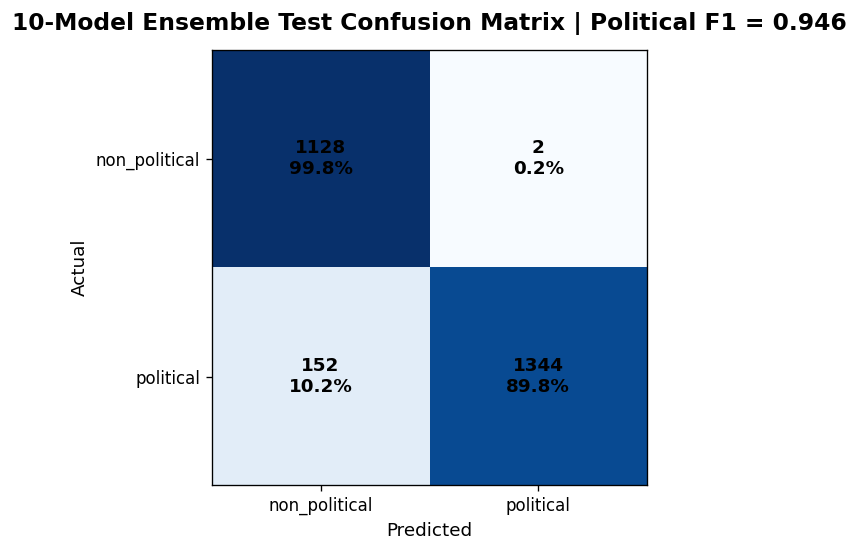

In [ ]:
confusion = test_evaluation["confusion_matrix"]

row_totals = confusion.sum(axis=1, keepdims=True)
confusion_percent = np.divide(
    confusion,
    row_totals,
    out=np.zeros_like(confusion, dtype=float),
    where=row_totals != 0,
) * 100

fig, ax = plt.subplots(figsize=(5.8, 4.7))
image = ax.imshow(
    confusion_percent,
    cmap="Blues",
    vmin=0,
    vmax=100,
)

ax.set_xticks(range(len(LABELS)))
ax.set_yticks(range(len(LABELS)))
ax.set_xticklabels(LABELS)
ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_title(
    f"10-Model Ensemble Test Confusion Matrix | Political F1 = "
    f"{test_evaluation['political_f1']:.3f}",
    pad=12,
    fontweight="bold",
)

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        count = int(confusion[i, j])
        percent = float(confusion_percent[i, j])

        ax.text(
            j,
            i,
            f"{count}\n{percent:.1f}%",
            ha="center",
            va="center",
            fontweight="bold",
            fontsize=11,
        )

plt.tight_layout()
plt.show()


---

## Additional Error Analysis

The tables below show a small number of false negatives and false positives from the final ensemble.

This helps explain where the classifier still fails without overwhelming the notebook with unnecessary output.


In [ ]:
false_negatives_df = (
    predictions_df[
        (predictions_df["true_label"] == POSITIVE_LABEL)
        & (predictions_df["predicted_label"] == NEGATIVE_LABEL)
    ]
    .sort_values(
        ["political_votes_out_of_10", "mean_political_probability"],
        ascending=[False, False],
    )
    .head(5)
)

false_positives_df = (
    predictions_df[
        (predictions_df["true_label"] == NEGATIVE_LABEL)
        & (predictions_df["predicted_label"] == POSITIVE_LABEL)
    ]
    .sort_values(
        ["political_votes_out_of_10", "mean_political_probability"],
        ascending=[False, False],
    )
    .head(5)
)

print("False negatives - political SMS missed by the ensemble:")
display_rtl_table(false_negatives_df)

print("\nFalse positives - non-political SMS predicted as political:")
if len(false_positives_df) == 0:
    print("No false positives in this Test run.")
else:
    display_rtl_table(false_positives_df)


False negatives - political SMS missed by the ensemble:


,message,true_label,predicted_label,political_votes_out_of_10,mean_political_probability,correct
631,"ממשלת קיצונים, בחירות 6 או ראש ממשלה חדש - אלו התרחישים בבחירות הקרובות. צפו בראיון של יו״ר המחנה הממלכתי, שר הביטחון בני גנץ, לאופירה וברקו, מסביר מדוע רק הוא יכול להרכיב ממשלה יציבה. לראיון - להסרה -",political,non_political,5,0.598600,False
1072,"סקר מעריב: בנט המפלגה המובילה בגוש מתחזק ועולה ל22 מנדטים. גוש המשרתים בראשותו עולה ל-60 מנדטים🇮🇱. עם ישראל היקר, תרימו ראש אנחנו ננצח ונתקן. הצטרפו לנצחון> הסר",political,non_political,3,0.354300,False
446,בחירות לראשות העיר חיפה בצל המלחמה: מדגם קצר על המתמודדים לראשות העיר והנושאים הבוערים בחיפה בצל המלחמה. המדגם נפתח. השפיעו >>>,political,non_political,3,0.314400,False
1622,"יו""ר כחול לבן בני גנץ מסביר באיזה מחנה הוא: ""המחנה שלנו זה עם ישראל וכחול לבן זה של כולנו"". שתהיה שנה טובה, ושיהיה לנו - את האומץ להסכים! לינק לנאום המלא> לינק להצטרפות ותמיכה>",political,non_political,1,0.356400,False
2496,"כאן שאול מרידור, הצטרפתי לישר! עם איזנקוט. ישראל צריכה מנהיג כמו גדי, שיחזיר אותה למסלול. היחיד שיביא ביטחון ונצחון לישראל. להסרה שלח הסר ל:",political,non_political,1,0.265700,False



False positives - non-political SMS predicted as political:


,message,true_label,predicted_label,political_votes_out_of_10,mean_political_probability,correct
1944,אין עדיין תשובה על השטחי אש,non_political,political,10,0.960000,False
1391,זהו? הסתדרת לך? מה הייתה התקלה?,non_political,political,10,0.770600,False


---

## Explainability

Each Naive Bayes learner stores a learned conditional probability for every token.

For ensemble explainability, the notebook averages the learned log-conditional probabilities across the **10 learners**, then ranks the tokens that most strongly distinguish one class from the other.

This explains what the **ensemble as a whole** learned rather than inspecting only one learner.


In [ ]:
def ensemble_indicative_tokens(ensemble, id_to_token, top_n=10):
    log_conditionals = np.stack([
        model.log_conditional_
        for model in ensemble.models_
    ])

    mean_log_conditional = log_conditionals.mean(axis=0)
    classes = ensemble.models_[0].classes_

    rows = []

    for class_index, class_name in enumerate(classes):
        other_indices = [
            i for i in range(len(classes))
            if i != class_index
        ]

        mean_other = mean_log_conditional[other_indices].mean(axis=0)
        scores = mean_log_conditional[class_index] - mean_other
        top_token_ids = np.argsort(scores)[::-1][:top_n]

        for rank, token_id in enumerate(top_token_ids, start=1):
            rows.append({
                "class": class_name,
                "rank": rank,
                "token": id_to_token[int(token_id)],
                "score": float(scores[int(token_id)]),
            })

    return pd.DataFrame(rows)


indicative_tokens_df = ensemble_indicative_tokens(
    final_ensemble,
    id_to_token,
    top_n=10,
)

political_tokens = (
    indicative_tokens_df[
        indicative_tokens_df["class"] == POSITIVE_LABEL
    ][["rank", "token", "score"]]
    .rename(columns={
        "token": "political_token",
        "score": "political_score",
    })
    .reset_index(drop=True)
)

non_political_tokens = (
    indicative_tokens_df[
        indicative_tokens_df["class"] == NEGATIVE_LABEL
    ][["rank", "token", "score"]]
    .rename(columns={
        "token": "non_political_token",
        "score": "non_political_score",
    })
    .reset_index(drop=True)
)

explainability_table = pd.concat(
    [
        political_tokens[["rank", "political_token", "political_score"]],
        non_political_tokens[["non_political_token", "non_political_score"]],
    ],
    axis=1,
)

explainability_table["political_score"] = (
    explainability_table["political_score"].round(3)
)
explainability_table["non_political_score"] = (
    explainability_table["non_political_score"].round(3)
)

print("Most indicative tokens learned across the 10-model ensemble:")
display_rtl_table(
    explainability_table,
    text_columns=("political_token", "non_political_token"),
)


Most indicative tokens learned across the 10-model ensemble:


,rank,political_token,political_score,non_political_token,non_political_score
0,1,היית,6.636000,https,7.425000
1,2,לתשובה,6.135000,il,7.004000
2,3,החלטתי,6.107000,להסרה,6.829000
3,4,פוליטי,6.026000,co,6.705000
4,5,המתאימה,6.016000,bit,6.543000
5,6,באפשרות,6.016000,ly,6.442000
6,7,לדעתך,5.955000,rm,6.002000
7,8,בחירות,5.940000,hasr,5.990000
8,9,קצרה,5.926000,me,5.833000
9,10,בחירה,5.899000,סטודנטים,5.738000


### Reusable prediction helper

This helper applies the exact final pipeline to new SMS messages:

`preprocessing → vocabulary encoding → 10 Naive Bayes predictions → majority vote`


In [ ]:
def predict_sms(messages):
    if isinstance(messages, str):
        messages = [messages]

    token_lists = tokenize_messages(
        messages,
        best_feature_config,
    )

    encoded = encode_documents(
        token_lists,
        final_vocab,
    )

    details = final_ensemble.predict_details(encoded)

    return pd.DataFrame({
        "message": messages,
        "predicted_label": details["predictions"],
        "political_votes_out_of_10": details["political_votes"],
        "mean_political_probability": np.round(
            details["mean_political_probability"],
            4,
        ),
    })


---

## Conclusions

The final classifier is a **Balanced Ensemble of 10 Multinomial Naive Bayes learners**.

The workflow is:

1. load the fixed Kaggle Train/Test split;
2. perform Hebrew-aware feature engineering;
3. implement Multinomial Naive Bayes from scratch;
4. use 5-fold CV and a 240-combination grid search on Train to select the shared base configuration;
5. validate the complete 10-model ensemble using Train-only 5-fold CV;
6. train ten independently sampled balanced learners on the full Train set;
7. classify every Test SMS by **majority vote**;
8. evaluate the final votes using Political F1, supporting metrics and a confusion matrix;
9. compare against the trivial majority-class baseline;
10. inspect errors and the tokens learned across the ensemble.

The Test labels are never used for training or model selection.

The ensemble design is especially appropriate for this project because the individual classifiers literally **vote** on the final election-SMS classification.
